In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df_resultados = pd.read_csv(
    "../dados/bruto/RESULTADOS_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_participantes = pd.read_csv(
    "../dados/bruto/PARTICIPANTES_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_resultados.shape, df_participantes.shape

((4332944, 42), (4332944, 38))

In [3]:
df_go_resultados = df_resultados[df_resultados["SG_UF_PROVA"] == "GO"]
df_go_participantes = df_participantes[df_participantes["SG_UF_PROVA"] == "GO"]

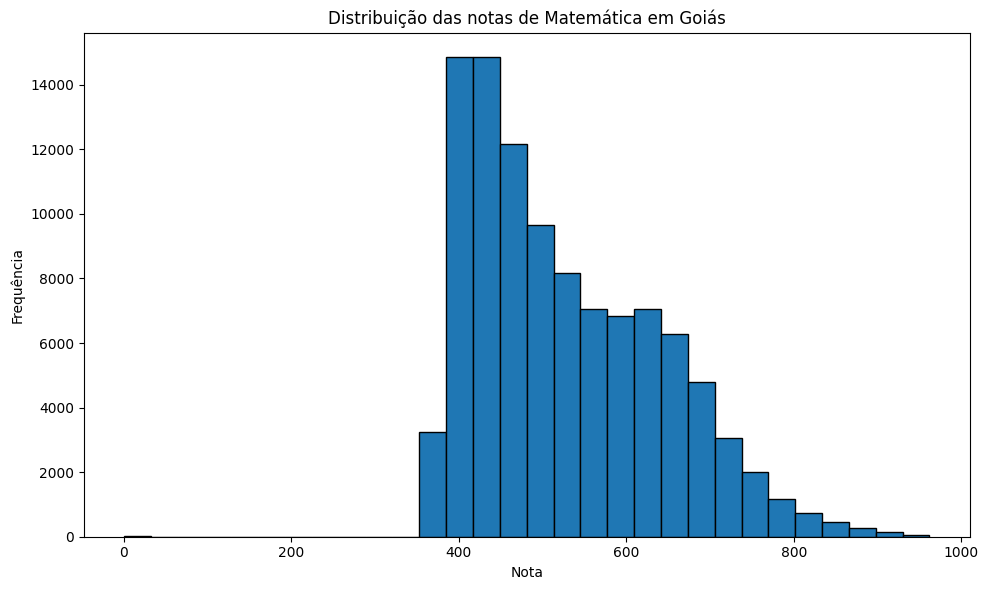

In [9]:
import matplotlib.pyplot as plt

# remover valores nulos da coluna de Matemática
df_go_mt = df_go_resultados.dropna(subset=["NU_NOTA_MT"])

# criar histograma
plt.figure(figsize=(10, 6))
plt.hist(df_go_mt["NU_NOTA_MT"], bins=30, edgecolor="black")

plt.title("Distribuição das notas de Matemática em Goiás")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.tight_layout()
plt.savefig("hist_go.png", dpi=300)
plt.show()

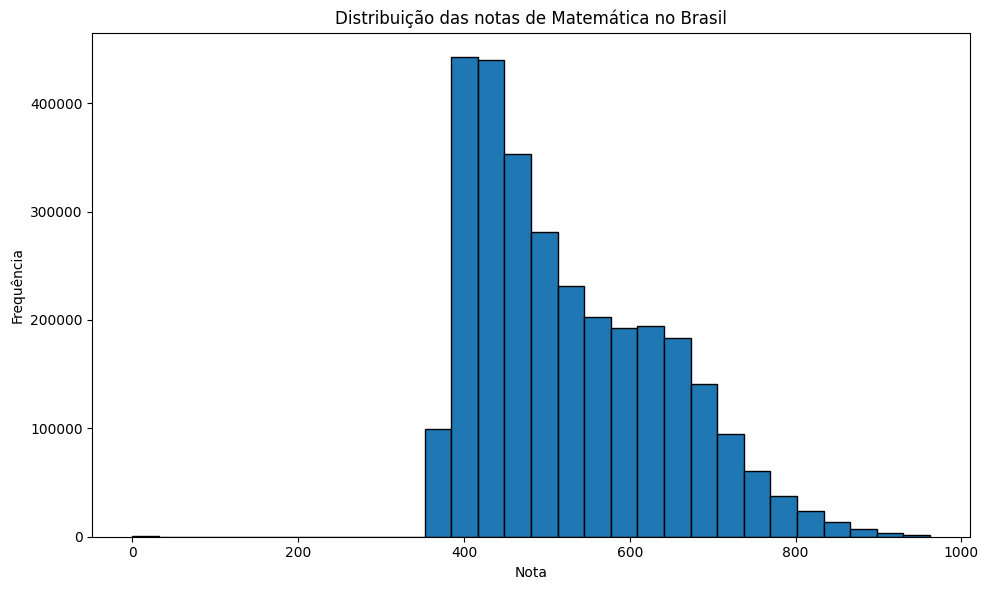

In [10]:
import matplotlib.pyplot as plt

df_br_mt = df_resultados.dropna(subset=["NU_NOTA_MT"])

plt.figure(figsize=(10, 6))
plt.hist(df_br_mt["NU_NOTA_MT"], bins=30, edgecolor="black")

plt.title("Distribuição das notas de Matemática no Brasil")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.tight_layout()
plt.savefig("hist_br.png", dpi=300)
plt.show()

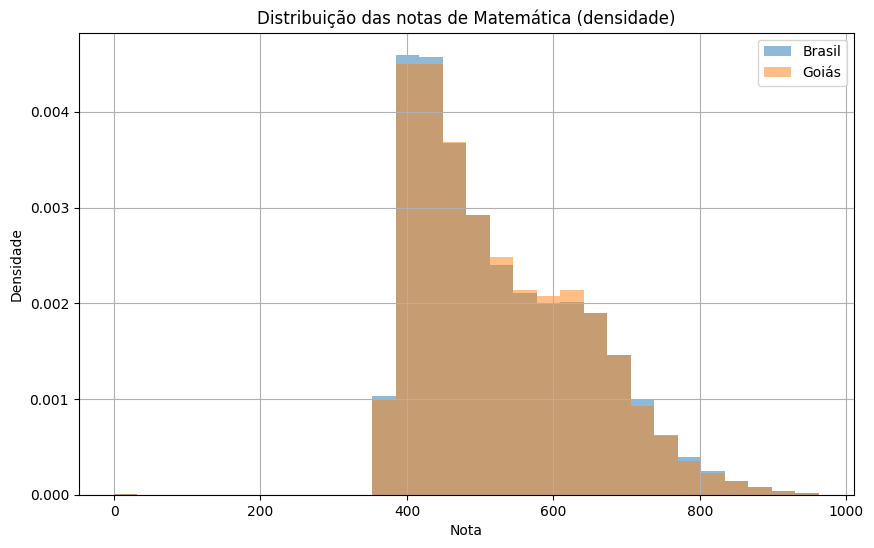

In [11]:
import matplotlib.pyplot as plt

# removendo NaN
df_go = df_go_resultados.dropna(subset=["NU_NOTA_MT"])
df_br = df_resultados.dropna(subset=["NU_NOTA_MT"])

plt.figure(figsize=(10,6))

plt.hist(df_br["NU_NOTA_MT"], bins=30, alpha=0.5, label="Brasil", density=True)
plt.hist(df_go["NU_NOTA_MT"], bins=30, alpha=0.5, label="Goiás", density=True)

plt.title("Distribuição das notas de Matemática (densidade)")
plt.xlabel("Nota")
plt.ylabel("Densidade")

plt.legend()
plt.grid(True)

plt.savefig("hist_comparacao.png", dpi=300)
plt.show()

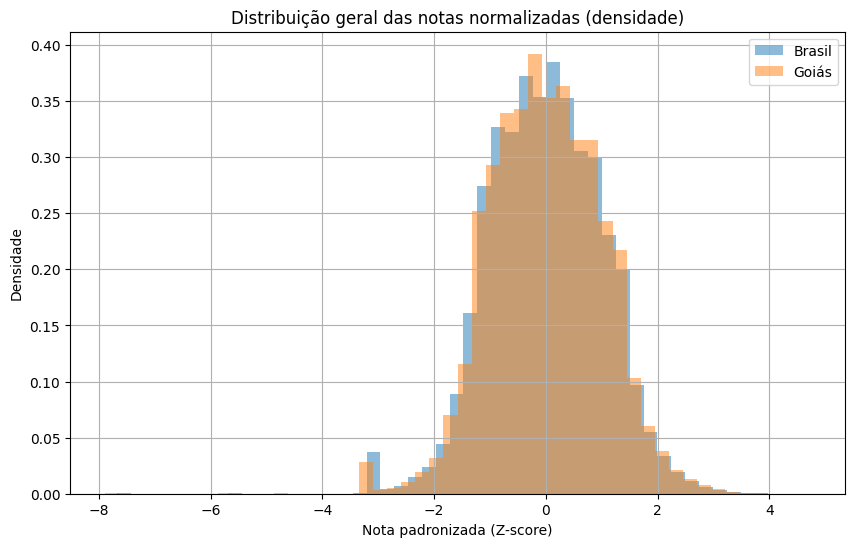

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# selecionar colunas
cols = ["NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_CH", "NU_NOTA_CN", "NU_NOTA_REDACAO"]

# remover NaN
df_br = df_resultados[cols].dropna()
df_go = df_go_resultados[cols].dropna()

# normalizar (z-score)
df_br_norm = (df_br - df_br.mean()) / df_br.std()
df_go_norm = (df_go - df_go.mean()) / df_go.std()

# transformar em uma única série
br_values = df_br_norm.values.flatten()
go_values = df_go_norm.values.flatten()

# plot
plt.figure(figsize=(10,6))

plt.hist(br_values, bins=50, alpha=0.5, label="Brasil", density=True)
plt.hist(go_values, bins=50, alpha=0.5, label="Goiás", density=True)

plt.title("Distribuição geral das notas normalizadas (densidade)")
plt.xlabel("Nota padronizada (Z-score)")
plt.ylabel("Densidade")

plt.legend()
plt.grid(True)

plt.savefig("hist_geral.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Ler corretamente o CSV
df_resultados = pd.read_csv(
    "../dados/bruto/RESULTADOS_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

# 2️⃣ Filtrar Goiás
df_go = df_resultados[df_resultados["SG_UF_PROVA"] == "GO"].copy()

# 3️⃣ Criar Brasil (base completa)
df_br = df_resultados.copy()

# 4️⃣ Renomear colunas
df_go = df_go.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

df_br = df_br.rename(columns={
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
})

# 5️⃣ Definir áreas
areas = [
    "Linguagens",
    "Matemática",
    "Ciências Humanas",
    "Ciências da Natureza",
    "Redação"
]

# 6️⃣ Remover NaN
df_go = df_go[areas].dropna()
df_br = df_br[areas].dropna()


Quantidade de dados duplicados

In [ ]:
# Antes da limpeza
duplicados_br = df_resultados.duplicated().sum()
duplicados_go = df_resultados[df_resultados["SG_UF_PROVA"] == "GO"].duplicated().sum()

# Depois da limpeza (supondo que você já removeu duplicados)
br = df_resultados.drop_duplicates()
go = br[br["SG_UF_PROVA"] == "GO"]

print("Dados Brasil após limpeza:", len(br))
print("Dados Goiás após limpeza:", len(go))


Quantos dados estamos analisando

In [ ]:
print("Total Brasil:", len(br))
print("Total Goiás:", len(go))


Alunos ausentes por disciplina

In [ ]:
# Dicionário de renomeação
renomear = {
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática",
    "NU_NOTA_CH": "Ciências Humanas",
    "NU_NOTA_CN": "Ciências da Natureza",
    "NU_NOTA_REDACAO": "Redação"
}

# Aplica renomeação
br = df_resultados.rename(columns=renomear)
go = br[br["SG_UF_PROVA"] == "GO"]

# Lista de áreas já normalizada
areas = ["Linguagens", "Matemática", "Ciências Humanas", "Ciências da Natureza", "Redação"]


In [ ]:
# Proporção de ausentes
prop_ausentes_br = ausentes_br / len(br) * 100
prop_ausentes_go = ausentes_go / len(go) * 100

# Proporção de zeros
prop_zeros_br = zeros_br / len(br) * 100
prop_zeros_go = zeros_go / len(go) * 100

print("Proporção de ausentes Brasil (%):\n", prop_ausentes_br)
print("Proporção de ausentes Goiás (%):\n", prop_ausentes_go)

print("Proporção de zeros Brasil (%):\n", prop_zeros_br)
print("Proporção de zeros Goiás (%):\n", prop_zeros_go)


In [ ]:
# Cria DataFrame com proporções de ausentes
tabela_ausentes = pd.DataFrame({
    "Disciplina": ausentes_br.index,
    "Brasil (%)": (ausentes_br / len(br) * 100).round(2),
    "Goiás (%)": (ausentes_go / len(go) * 100).round(2)
})

# Cria DataFrame com proporções de notas zeradas
tabela_zeros = pd.DataFrame({
    "Disciplina": zeros_br.index,
    "Brasil (%)": (zeros_br / len(br) * 100).round(2),
    "Goiás (%)": (zeros_go / len(go) * 100).round(2)
})

print("📊 Proporção de Ausentes (%):")
display(tabela_ausentes)

print("\n📊 Proporção de Notas Zeradas (%):")
display(tabela_zeros)


In [ ]:
# Quantidade de registros antes da limpeza
total_br_antes = len(df_resultados)
total_go_antes = len(df_resultados[df_resultados["SG_UF_PROVA"] == "GO"])

print("Total Brasil antes da limpeza:", total_br_antes)
print("Total Goiás antes da limpeza:", total_go_antes)

# Quantidade de registros depois da limpeza
total_br_depois = len(br)
total_go_depois = len(go)

print("Total Brasil depois da limpeza:", total_br_depois)
print("Total Goiás depois da limpeza:", total_go_depois)

# Diferença (quantos registros foram removidos)
print("Removidos Brasil:", total_br_antes - total_br_depois)
print("Removidos Goiás:", total_go_antes - total_go_depois)


In [ ]:
# Copia a base original
df_limpo = df_resultados.copy()

# 1. Remover duplicados
print("Duplicados antes:", df_limpo.duplicated().sum())
df_limpo = df_limpo.drop_duplicates()
print("Duplicados depois:", df_limpo.duplicated().sum())

# 2. Validar intervalos das notas (0 a 1000)
areas_notas = ["NU_NOTA_LC","NU_NOTA_MT","NU_NOTA_CH","NU_NOTA_CN","NU_NOTA_REDACAO"]
for col in areas_notas:
    df_limpo = df_limpo[(df_limpo[col].isna()) | ((df_limpo[col] >= 0) & (df_limpo[col] <= 1000))]

# 3. Remover registros sem nenhuma nota (todos ausentes)
df_limpo = df_limpo.dropna(subset=areas_notas, how="all")

# 4. Separar Brasil e Goiás
br = df_limpo
go = df_limpo[df_limpo["SG_UF_PROVA"] == "GO"]

# 5. Print comparativo
print("=== Diagnóstico da Limpeza ===")
print(f"Brasil - Antes: {len(df_resultados):,} | Depois: {len(br):,} | Removidos: {len(df_resultados) - len(br):,}")
print(f"Goiás  - Antes: {len(df_resultados[df_resultados['SG_UF_PROVA']=='GO']):,} | Depois: {len(go):,} | Removidos: {len(df_resultados[df_resultados['SG_UF_PROVA']=='GO']) - len(go):,}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcula proporções (%)
prop_ausentes_br = ausentes_br / len(br) * 100
prop_ausentes_go = ausentes_go / len(go) * 100

prop_zeros_br = zeros_br / len(br) * 100
prop_zeros_go = zeros_go / len(go) * 100

# Cria DataFrames para proporções
df_ausentes = pd.DataFrame({
    "Brasil (%)": prop_ausentes_br,
    "Goiás (%)": prop_ausentes_go
}).reset_index().rename(columns={"index": "Disciplina"})

df_zeros = pd.DataFrame({
    "Brasil (%)": prop_zeros_br,
    "Goiás (%)": prop_zeros_go
}).reset_index().rename(columns={"index": "Disciplina"})

# Gráfico de ausentes (%)
plt.figure(figsize=(10,6))
df_ausentes_melt = df_ausentes.melt(id_vars="Disciplina", var_name="Região", value_name="Percentual")
sns.barplot(data=df_ausentes_melt, x="Disciplina", y="Percentual", hue="Região")
plt.title("Proporção de Alunos Ausentes por Disciplina")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=45)
plt.show()

# Gráfico de notas zeradas (%)
plt.figure(figsize=(10,6))
df_zeros_melt = df_zeros.melt(id_vars="Disciplina", var_name="Região", value_name="Percentual")
sns.barplot(data=df_zeros_melt, x="Disciplina", y="Percentual", hue="Região")
plt.title("Proporção de Notas Zeradas por Disciplina")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=45)
plt.show()

